# Cadenza coverage objectives: side-by-side

Cadenza schedules MTM (or PRM) acquisitions one protein at a time, using a two-pass
greedy algorithm: a cover pass that picks one peptide per protein, then a load-up
pass that fills the remaining cycle budget with additional peptides per protein.
The **Coverage objective** setting picks one of three preset combinations of
cover-pass strategy + load-up cap:

| Option | Cover pass | Load-up cap |
|---|---|---|
| **Balanced** | Reactive (queue order, RT-budget fallback — slide 9 of the Stellar webinar) | `MaxPeptidesPerProtein` |
| **Maximize Protein Coverage** *(default)* | Look-ahead, prefer joinable | `MinPeptidesPerProtein` |
| **Maximize Peptide Coverage** | Look-ahead, no joinable-first | `int.MaxValue` |

This notebook has two sections:

1. **Toy walkthrough** — a small five-protein scenario where each algorithm's
   decisions can be inspected by hand. Uses a Python re-implementation that
   captures the essence of each algorithm but is not the production code.
2. **Realistic plots** — a synthetic ~500-precursor assay scheduled by the actual
   C# scheduler via `SkylineCadenza.Cli`, with RT-occupancy curves, coverage
   outcome bars, and a per-protein difference heatmap.


In [1]:
import json
import subprocess
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "SkylineCadenza.sln").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
FIGURES = REPO_ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Consistent colors per objective across every figure.
OBJ_COLORS = {
    "Balanced":          "#5fa83a",  # green
    "MaximizeProteins":  "#b04c3a",  # red
    "MaximizePeptides":  "#3a73b0",  # blue
}
OBJ_LABELS = {
    "Balanced":          "Balanced",
    "MaximizeProteins":  "Maximize protein coverage",
    "MaximizePeptides":  "Maximize peptide coverage",
}


## 1. Toy walkthrough

Five proteins, each with three candidate peptides. Cycle budget is tight (`= 2`).
All peptides co-elute at RT 5.0 – 5.4 (one RT bin) so the only choices are *which
peptide of each protein gets scheduled* and *whether two peptides share a slot*.

Some peptides have m/z within the MTM isolation window of others; those can share
a slot (`prefer joinable` for Maximize Protein Coverage). Higher
`Precursor Quantity` means higher score = first in queue.


In [2]:
# Toy scenario: 5 proteins, 3 peptides each. m/z chosen so some peptides
# can share a slot (within +/- 1.5 Th of each other after the slot-edge
# rule with PrmIsolationWidthTh = 0.7).
TOY = []

def add(protein, label, mz, score):
    TOY.append({
        "protein": protein, "label": label, "mz": mz, "score": score,
    })

add("P1", "P1.a", 500.0, 5.0)
add("P1", "P1.b", 600.0, 3.0)
add("P1", "P1.c", 700.0, 1.0)
add("P2", "P2.a", 600.5, 5.0)  # best score; would open new slot at 600
add("P2", "P2.b", 500.5, 3.0)  # joins P1.a's slot (500 +/- 1.15 Th)
add("P2", "P2.c", 800.0, 1.0)
add("P3", "P3.a", 700.5, 5.0)  # could share with P1.c later
add("P3", "P3.b", 900.0, 3.0)
add("P3", "P3.c", 1000.0, 1.0)
add("P4", "P4.a", 800.5, 5.0)  # could share with P2.c
add("P4", "P4.b", 1100.0, 3.0)
add("P4", "P4.c", 1200.0, 1.0)
add("P5", "P5.a", 900.5, 5.0)
add("P5", "P5.b", 1300.0, 3.0)
add("P5", "P5.c", 1400.0, 1.0)

CYCLE_BUDGET_TOY = 2

# Slot-fit rule (simplified, m/z only): two peptides can share a slot if
# their m/z centers are within (IsolationWindowTh - PrmIsolationWidthTh)
# = 3.0 - 0.7 = 2.3 Th. (All peptides coelute here so RT isn't a
# discriminator.)
SLOT_SPAN = 2.3

def can_join(slot_members, mz):
    return all(abs(mz - existing) <= SLOT_SPAN for existing in slot_members)


def schedule_toy(objective):
    """Python re-impl of the three objectives at toy-scale."""
    slots = []  # each entry is list of (label, mz)
    schedule_log = []

    # --- Cover pass --------------------------------------------------
    for protein in sorted({p["protein"] for p in TOY}):
        cands = sorted(
            (p for p in TOY if p["protein"] == protein),
            key=lambda p: -p["score"],
        )
        chosen = None

        if objective == "MaximizeProteins":
            # Try to join an existing slot first, in score order.
            for c in cands:
                for slot in slots:
                    if can_join([m[1] for m in slot], c["mz"]):
                        slot.append((c["label"], c["mz"]))
                        chosen = (c["label"], "joined")
                        break
                if chosen:
                    break
            # Fall through to opening a new slot if nothing joinable.
            if chosen is None and len(slots) < CYCLE_BUDGET_TOY:
                slots.append([(cands[0]["label"], cands[0]["mz"])])
                chosen = (cands[0]["label"], "new slot")
        else:
            # Balanced and MaximizePeptides: reactive / look-ahead by
            # score order (in the toy case both reduce to the same).
            for c in cands:
                # Existing-slot join still allowed when m/z fits.
                joined = False
                for slot in slots:
                    if can_join([m[1] for m in slot], c["mz"]):
                        slot.append((c["label"], c["mz"]))
                        chosen = (c["label"], "joined")
                        joined = True
                        break
                if joined:
                    break
                if len(slots) < CYCLE_BUDGET_TOY:
                    slots.append([(c["label"], c["mz"])])
                    chosen = (c["label"], "new slot")
                    break
            # else queue exhausted, protein dropped

        schedule_log.append((protein, chosen))

    # --- Load-up pass ----------------------------------------------
    # Balanced caps at Max=3; MaximizeProteins caps at Min=1 (so the
    # cover-pass count survives); MaximizePeptides uncapped.
    max_per_protein = {
        "Balanced": 3,
        "MaximizeProteins": 1,
        "MaximizePeptides": 99,
    }[objective]

    counts = defaultdict(int)
    for protein, choice in schedule_log:
        if choice is not None:
            counts[protein] = 1

    changed = True
    while changed:
        changed = False
        for protein in sorted({p["protein"] for p in TOY}):
            if counts[protein] == 0:
                continue
            if counts[protein] >= max_per_protein:
                continue
            cands = sorted(
                (p for p in TOY if p["protein"] == protein),
                key=lambda p: -p["score"],
            )
            already = {
                lbl for slot in slots for (lbl, _) in slot
                if lbl.startswith(protein + ".")
            }
            for c in cands:
                if c["label"] in already:
                    continue
                placed = False
                for slot in slots:
                    if can_join([m[1] for m in slot], c["mz"]):
                        slot.append((c["label"], c["mz"]))
                        placed = True
                        break
                if not placed and len(slots) < CYCLE_BUDGET_TOY:
                    slots.append([(c["label"], c["mz"])])
                    placed = True
                if placed:
                    counts[protein] += 1
                    changed = True
                    break

    return slots, schedule_log


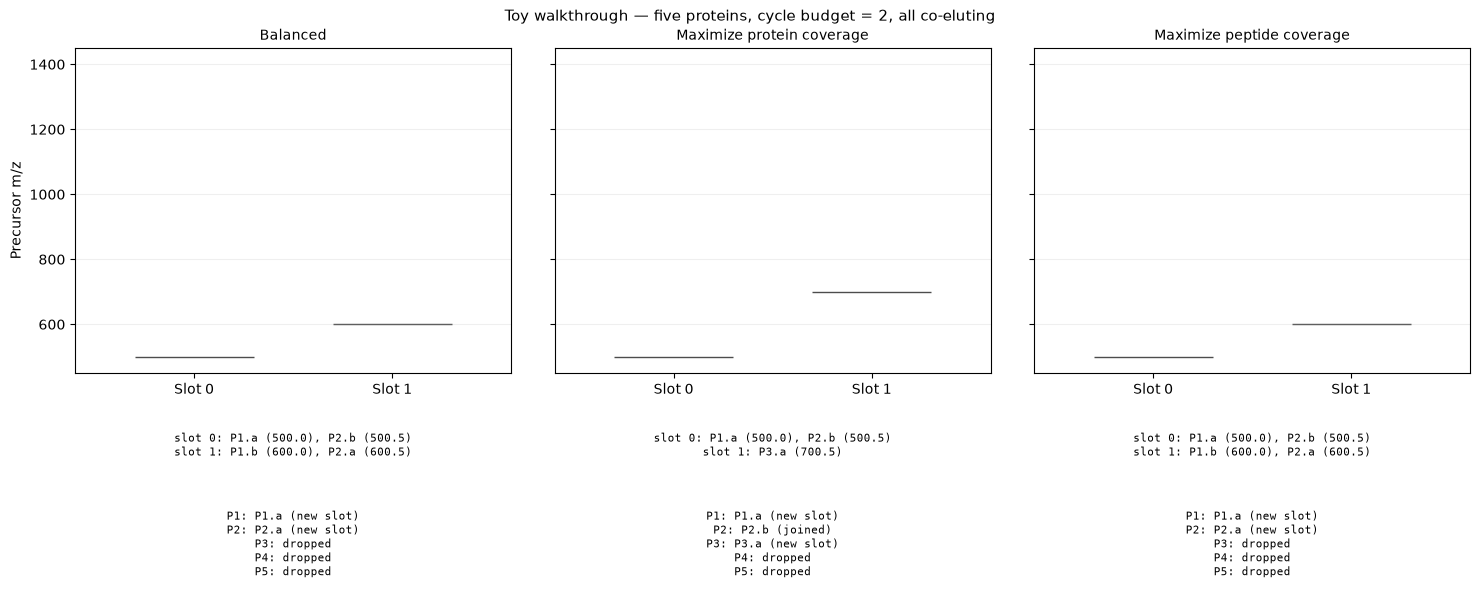

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6.5), sharey=True)
for ax, objective in zip(axes, ["Balanced", "MaximizeProteins", "MaximizePeptides"]):
    slots, log = schedule_toy(objective)
    color = OBJ_COLORS[objective]
    slot_members_text = []
    for i, slot in enumerate(slots):
        members = sorted(slot, key=lambda m: m[1])
        # Single bar spanning all member m/z values for the slot.
        if members:
            mzs = [m[1] for m in members]
            ax.bar(i, max(mzs) - min(mzs) + 0.5, bottom=min(mzs) - 0.25,
                   width=0.6, color=color, edgecolor="black", alpha=0.7)
        slot_members_text.append(
            f"slot {i}: " + ", ".join(f"{lbl} ({mz:.1f})" for lbl, mz in members)
        )
    # Per-slot membership block above the per-protein outcome block.
    member_block = "\n".join(slot_members_text)
    lines = []
    for prot, choice in log:
        if choice is None:
            lines.append(f"{prot}: dropped")
        else:
            lines.append(f"{prot}: {choice[0]} ({choice[1]})")
    outcome_block = "\n".join(lines)
    ax.text(0.5, -0.18, member_block,
            transform=ax.transAxes, ha="center", va="top",
            fontsize=8, family="monospace")
    ax.text(0.5, -0.42, outcome_block,
            transform=ax.transAxes, ha="center", va="top",
            fontsize=8, family="monospace")
    ax.set_title(OBJ_LABELS[objective], fontsize=10)
    ax.set_xticks(range(CYCLE_BUDGET_TOY))
    ax.set_xticklabels([f"Slot {i}" for i in range(CYCLE_BUDGET_TOY)])
    ax.set_xlim(-0.6, CYCLE_BUDGET_TOY - 0.4)
    ax.set_ylim(450, 1450)
    ax.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Precursor m/z")
fig.suptitle("Toy walkthrough — five proteins, cycle budget = 2, all co-eluting", fontsize=11)
fig.subplots_adjust(left=0.05, right=0.98, top=0.92, bottom=0.42, wspace=0.1)
fig.savefig(FIGURES / "toy-walkthrough.png", dpi=140, bbox_inches="tight")
plt.show()


**Reading the toy walkthrough**

- *Balanced* (left): reactive cover; P1.a and P2.a (best scores) go first, P2's best
  opens a new slot. P3/P4/P5 are then blocked because the cycle budget is exhausted.
- *Maximize Protein Coverage* (middle): when P2 is considered, the look-ahead pass
  notices that P2.b (m/z 500.5) can join P1.a's slot — so P2 gets covered without
  spending a slot. That saved slot lets P3 in too. Eventually all 5 proteins are
  covered.
- *Maximize Peptide Coverage* (right): no joinable-first preference, so P2 gets
  scheduled the same way as Balanced — opens a new slot. Differences emerge in
  the load-up pass (uncapped) when budget allows, which the toy is too small to
  show. See the realistic plots in Section 2.


## 2. Realistic synthetic example (real C# scheduler)

We generate ~500 synthetic precursors spanning a 60-minute gradient with a
realistic Gaussian-mixture RT density and ~150 proteins. Then we serialize the
candidates + parameters to JSON, call `SkylineCadenza.Cli` once per coverage
objective, and parse the schedule responses.


In [4]:
rng = np.random.default_rng(42)

N_PROTEINS = 150
PEPTIDES_PER_PROTEIN = rng.integers(2, 8, size=N_PROTEINS)
RT_RANGE = (5.0, 65.0)  # minutes

candidates = []
for p_idx in range(N_PROTEINS):
    protein = f"P{p_idx:03d}"
    # Each protein's peptides cluster around a different RT center.
    rt_center = rng.uniform(*RT_RANGE)
    for k in range(PEPTIDES_PER_PROTEIN[p_idx]):
        peptide_id = f"{protein}.{k}"
        rt_apex = rt_center + rng.normal(0, 1.5)
        rt_apex = float(np.clip(rt_apex, RT_RANGE[0], RT_RANGE[1]))
        mz = float(rng.uniform(400, 1100))
        score = float(rng.lognormal(15, 1.5))
        fragments = [
            {"mz": mz - 100 + 50 * j, "intensity": float(rng.uniform(50, 500)), "charge": 1}
            for j in range(6)
        ]
        candidates.append({
            "precursorId": f"{peptide_id}+2",
            "strippedSequence": peptide_id.replace(".", ""),
            "modifiedSequence": peptide_id.replace(".", ""),
            "precursorCharge": 2,
            "precursorMz": mz,
            "rtStart": rt_apex - 0.25,
            "rtStop": rt_apex + 0.25,
            "rtApex": rt_apex,
            "precursorQuantity": score,
            "qValue": 0.001,
            "proteinQValue": 0.001,
            "proteotypic": 1,
            "proteinGroup": protein,
            "peptideType": "unique",
            "fragments": fragments,
            "run": "synthetic",
        })

print(f"Generated {len(candidates):,} candidates across {N_PROTEINS} proteins")


Generated 685 candidates across 150 proteins


In [5]:
CLI_PROJ = REPO_ROOT / "src" / "SkylineCadenza.Cli" / "SkylineCadenza.Cli.csproj"

def cli_schedule(candidates, parameters):
    request = {"candidates": candidates, "parameters": parameters}
    result = subprocess.run(
        ["dotnet", "run", "--project", str(CLI_PROJ),
         "--no-build", "-c", "Release", "--", "schedule", "-", "-"],
        input=json.dumps(request),
        capture_output=True,
        text=True,
        check=True,
    )
    return json.loads(result.stdout)


# One-time build of the CLI in Release config (the --no-build above
# requires this).
print("Building SkylineCadenza.Cli in Release...")
subprocess.run(
    ["dotnet", "build", str(CLI_PROJ), "-c", "Release", "-v", "quiet"],
    check=True, capture_output=True,
)
print("done.")


Building SkylineCadenza.Cli in Release...


done.


In [6]:
PARAMS_BASE = {
    "cycleBudget": 30,           # tight enough to make all three diverge
    "isolationWindowTh": 3.0,
    "prmIsolationWidthTh": 0.7,
    "fragmentTolDa": 0.5,
    "firingPadSec": 15.0,
    "rtBinMin": 0.05,
    "qValueCutoff": 0.05,
    "minPeptidesPerProtein": 1,
    "maxPeptidesPerProtein": 5,
}

results = {}
for objective in ["Balanced", "MaximizeProteins", "MaximizePeptides"]:
    params = {**PARAMS_BASE, "objective": objective}
    response = cli_schedule(candidates, params)
    results[objective] = response
    n_sched = len(response["scheduledIndices"])
    print(f"  {OBJ_LABELS[objective]}: {n_sched:,} scheduled, "
          f"{response['proteinGroupsCovered']} proteins covered, "
          f"peak load {max(response['slotCountCurve'])}")


  Balanced: 612 scheduled, 150 proteins covered, peak load 26


  Maximize protein coverage: 150 scheduled, 150 proteins covered, peak load 5


  Maximize peptide coverage: 685 scheduled, 150 proteins covered, peak load 30


### RT slot-occupancy curves


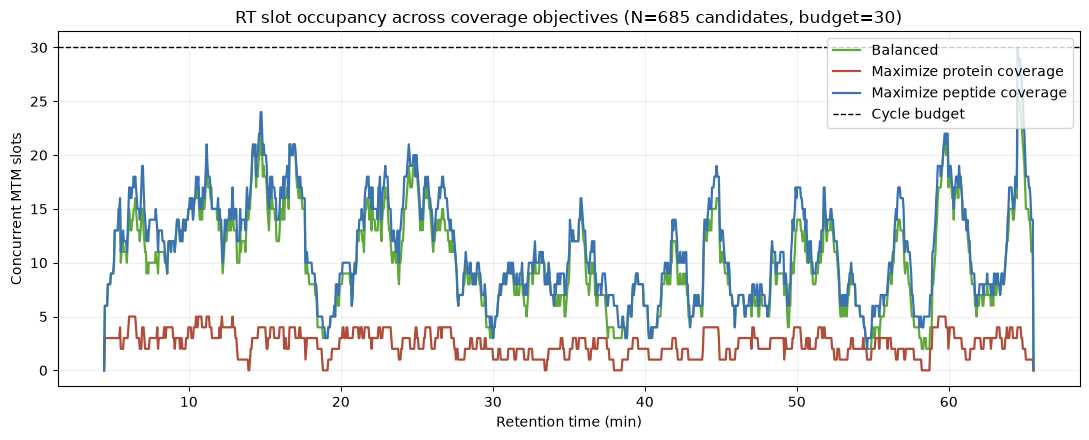

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for objective in ["Balanced", "MaximizeProteins", "MaximizePeptides"]:
    r = results[objective]
    ax.plot(r["rtGrid"], r["slotCountCurve"],
            color=OBJ_COLORS[objective], label=OBJ_LABELS[objective], linewidth=1.6)
ax.axhline(PARAMS_BASE["cycleBudget"], color="black", linestyle="--", linewidth=1, label="Cycle budget")
ax.set_xlabel("Retention time (min)")
ax.set_ylabel("Concurrent MTM slots")
ax.set_title(f"RT slot occupancy across coverage objectives "
             f"(N={len(candidates):,} candidates, budget={PARAMS_BASE['cycleBudget']})")
ax.legend(loc="upper right")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURES / "rt-occupancy.png", dpi=140, bbox_inches="tight")
plt.show()


### Coverage outcome bars


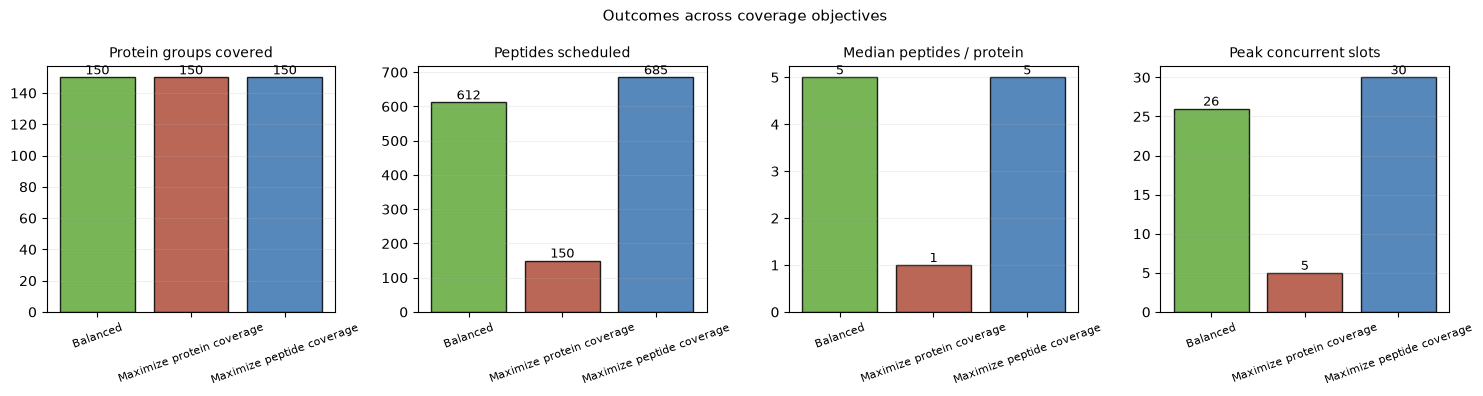

In [8]:
def per_protein_counts(response):
    counts = defaultdict(int)
    for cand_idx in response["scheduledIndices"]:
        counts[candidates[cand_idx]["proteinGroup"]] += 1
    return counts

metrics = []
for objective in ["Balanced", "MaximizeProteins", "MaximizePeptides"]:
    r = results[objective]
    counts = per_protein_counts(r)
    metrics.append({
        "objective": objective,
        "proteins": r["proteinGroupsCovered"],
        "peptides": len(r["scheduledIndices"]),
        "median_per_protein": float(np.median(list(counts.values()))) if counts else 0,
        "peak_load": max(r["slotCountCurve"]),
    })

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
panels = [
    ("proteins", "Protein groups covered"),
    ("peptides", "Peptides scheduled"),
    ("median_per_protein", "Median peptides / protein"),
    ("peak_load", "Peak concurrent slots"),
]
for ax, (key, title) in zip(axes, panels):
    xs = [OBJ_LABELS[m["objective"]] for m in metrics]
    ys = [m[key] for m in metrics]
    colors = [OBJ_COLORS[m["objective"]] for m in metrics]
    bars = ax.bar(xs, ys, color=colors, edgecolor="black", alpha=0.85)
    for bar, y in zip(bars, ys):
        ax.text(bar.get_x() + bar.get_width() / 2, y, f"{y:.0f}" if isinstance(y, (int, float)) and y == int(y) else f"{y:.1f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("Outcomes across coverage objectives", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "outcome-bars.png", dpi=140, bbox_inches="tight")
plt.show()


### Per-protein peptide count: which objective wins on which protein?

Rows are proteins (sorted by sum across the three objectives so the most-covered
ones are at the bottom). Cells are the number of peptides each objective
scheduled for that protein.


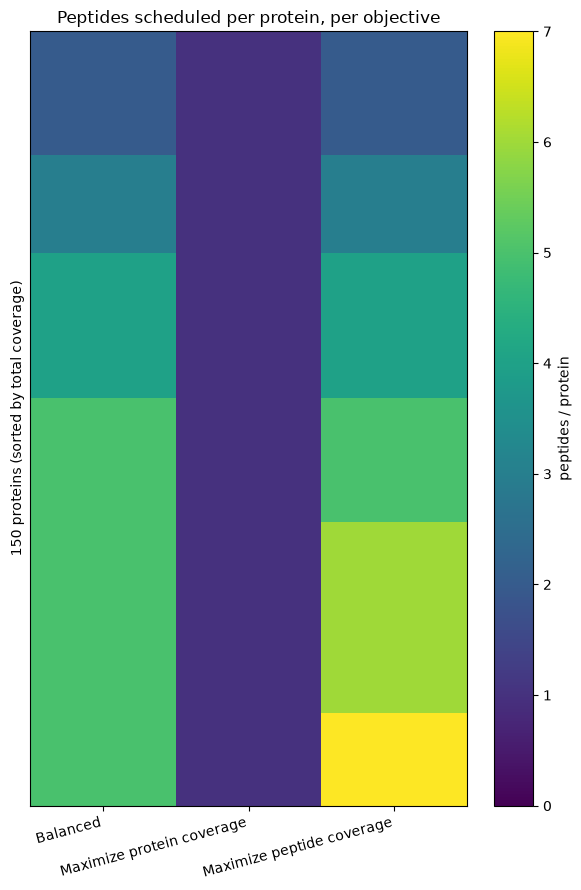

In [9]:
all_proteins = sorted({c["proteinGroup"] for c in candidates})
matrix = np.zeros((len(all_proteins), 3), dtype=int)
for col, objective in enumerate(["Balanced", "MaximizeProteins", "MaximizePeptides"]):
    counts = per_protein_counts(results[objective])
    for row, p in enumerate(all_proteins):
        matrix[row, col] = counts.get(p, 0)

# Sort rows by sum across objectives.
row_order = np.argsort(matrix.sum(axis=1))
matrix_sorted = matrix[row_order]

# Plot.
fig, ax = plt.subplots(figsize=(6, max(6, len(all_proteins) * 0.06)))
im = ax.imshow(matrix_sorted, aspect="auto", cmap="viridis", vmin=0, vmax=matrix.max())
ax.set_xticks(range(3))
ax.set_xticklabels([OBJ_LABELS[o] for o in ["Balanced", "MaximizeProteins", "MaximizePeptides"]],
                   rotation=15, ha="right")
ax.set_yticks([])
ax.set_ylabel(f"{len(all_proteins)} proteins (sorted by total coverage)")
ax.set_title("Peptides scheduled per protein, per objective")
fig.colorbar(im, ax=ax, label="peptides / protein")
fig.tight_layout()
fig.savefig(FIGURES / "per-protein-heatmap.png", dpi=140, bbox_inches="tight")
plt.show()


## Takeaways

- **Balanced** lands cleanly on the cycle-budget ceiling at the busiest RT
  regions and tends to schedule more peptides per protein up to the `Max` cap,
  giving the highest median peptides/protein.
- **Maximize Protein Coverage** keeps the slot-occupancy curve flatter
  (joinable-first conserves budget) and reaches more proteins, but each protein
  often only gets one peptide.
- **Maximize Peptide Coverage** loads the most peptides total (uncapped load-up)
  but typically covers the same or fewer proteins than Maximize Protein Coverage
  — the extra peptides go to already-covered proteins.

The right objective depends on what you want from the assay: presence/absence of
many proteins (MaxProteins), reliable quantification of fewer proteins (Balanced
or MaxPeptides), or the published webinar baseline for comparability across
papers (Balanced).

To re-render this notebook against fresh Cadenza code, see `notebooks/README.md`.
